# Fashion-MNIST Classification using ANN

In [1]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models

In [2]:
train_df = pd.read_csv("fashion-mnist_train.csv")
test_df = pd.read_csv("fashion-mnist_test.csv")

In [3]:
y_train = train_df.iloc[:, 0].values
x_train = train_df.iloc[:, 1:].values

In [4]:
y_test = test_df.iloc[:, 0].values
x_test = test_df.iloc[:, 1:].values

In [5]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [6]:
model = models.Sequential(
    [
        layers.Input(shape=(784,)),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax"),  # 10 farklı kıyafet sınıfı için
    ]
)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [8]:
history = model.fit(
    x_train, y_train, epochs=5, batch_size=64, validation_split=0.1
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.8150 - loss: 0.5238 - val_accuracy: 0.8435 - val_loss: 0.4323
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8606 - loss: 0.3836 - val_accuracy: 0.8713 - val_loss: 0.3613
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8746 - loss: 0.3456 - val_accuracy: 0.8717 - val_loss: 0.3724
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8805 - loss: 0.3246 - val_accuracy: 0.8705 - val_loss: 0.3572
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8881 - loss: 0.3024 - val_accuracy: 0.8793 - val_loss: 0.3386


In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 328,160 (1.25 MB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 218,774 (854.59 KB)

In [11]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
test_acc

313/313 - 1s - 3ms/step - accuracy: 0.8836 - loss: 0.3157


0.8835999965667725

In [18]:
test_loss

0.3156515657901764

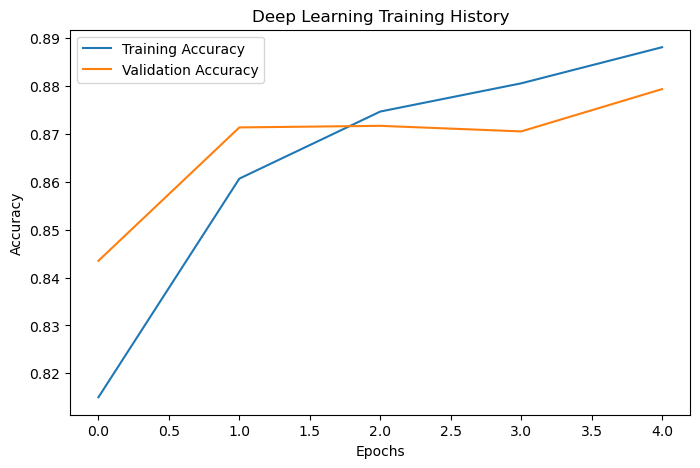

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Deep Learning Training History")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [19]:
# Conclusion: The deep learning model is successfully trained, evaluated, and saved into the Deep-Learning folder with %88 accuracy.

In [20]:
model.save("fashion_mnist_model.h5")